<div style="padding:12px 16px; border-left:6px solid #1f4ed8; background:#eef2ff;">
  <h2 style="margin:0; color:#1f4ed8; font-weight:800;">Project 1</h2>
  <p style="margin:4px 0 0 0; font-size:16px; color:#0f172a;">
    Prepared by <strong>Ayush Mishra</strong> (<span style="color:#1f4ed8; font-weight:600;">Unified Mentor Intern</span>)
  </p>
</div>

<h1 style="margin:0; font-size:34px;">
  <span style="color:#1f4ed8; font-weight:800;">Inventory Purchase Analytics</span>
</h1>

<p style="font-size:16px;">
  Analyze purchasing activity using your Data Folder. We load the invoice ledger and the price list snapshot, compute vendor/month metrics, and compare observed unit costs vs vendor price references.
</p>

<p>
  <span style="background:#e2e8f0; color:#0f172a; padding:4px 8px; border-radius:6px; font-weight:600;">Scope:</span>
  <span style="color:#334155;">Purchases, vendors, months, price reference comparison</span>
</p>

<p>
  <span style="background:#dbeafe; color:#1e40af; padding:4px 8px; border-radius:6px; font-weight:600;">Data Sources</span>
  <span style="color:#1f2937;">InvoicePurchases12312016.csv, 2017PurchasePricesDec.csv</span>
</p>

In [2]:
import csv
from collections import defaultdict
from datetime import datetime
import math

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")


## Setup Notes

- **Libraries:** Built-in Python (`csv`, `datetime`) for portability; adds `matplotlib` + `seaborn` for charts.
- **Paths:** Ensure the two file paths point to your “Data Folder”.
- **Kernel:** Use a **Python 3** kernel and run cells top-to-bottom.

> <span style="color:#7c3aed; font-weight:700;">Tip:</span> If you move files, update `INVOICE_FP` and `PRICES_FP` in the Setup cell.

In [3]:
INVOICE_FP = "/Users/macbook/Documents/Intern projects/inventory data analysis/Data Folder/InvoicePurchases12312016.csv"
PRICES_FP = "/Users/macbook/Documents/Intern projects/inventory data analysis/Data Folder/2017PurchasePricesDec.csv"


## Visualizations

We highlight:
- **Top Vendors by Spend**: concentration of spend across vendors.
- **Monthly Spend Trend**: seasonality and spikes.
- **Observed vs Reference Unit Cost**: pricing deviations and anomalies.
- **Freight Rate by Vendor**: freight efficiency relative to spend.

### Top Vendors by Spend

- Ranks vendors by **Total Dollars** (top 15 by default).
- Use to see **concentration risk** and **primary partners**.
- Change `top_n` to adjust depth; keep labels readable.

In [4]:
top_n = 15
top_vendors = vendor_aggs[:top_n]
labels = [r["VendorName"] for r in top_vendors]
values = [r["TotalDollars"] for r in top_vendors]

plt.figure(figsize=(12, 7))
sns.barplot(x=values, y=labels, orient="h", palette="Blues_r")
plt.title("Top Vendors by Spend")
plt.xlabel("Total Dollars")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

NameError: name 'vendor_aggs' is not defined

In [ ]:
def _num(x):
    try:
        return float(x)
    except:
        return 0.0

def _parse_date(s):
    try:
        return datetime.strptime(s, "%Y-%m-%d")
    except:
        return None


In [ ]:
def load_invoices(fp):
    rows = []
    with open(fp, newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            rows.append({
                "VendorName": (row.get("VendorName") or "").strip(),
                "InvoiceDate": _parse_date(row.get("InvoiceDate")),
                "Quantity": _num(row.get("Quantity")),
                "Dollars": _num(row.get("Dollars")),
                "Freight": _num(row.get("Freight"))
            })
    return rows

def load_prices(fp):
    rows = []
    with open(fp, newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            rows.append({
                "VendorName": (row.get("VendorName") or "").strip(),
                "Description": row.get("Description"),
                "PurchasePrice": _num(row.get("PurchasePrice"))
            })
    return rows

invoices = load_invoices(INVOICE_FP)
prices = load_prices(PRICES_FP)


## Dataset Dictionary

| Dataset | Key Fields | Meaning |
|---|---|---|
| <span style="color:#0ea5e9; font-weight:700;">Invoices</span> | VendorName, InvoiceDate, Quantity, Dollars, Freight | Purchase ledger lines per vendor and date |
| <span style="color:#f59e0b; font-weight:700;">Prices</span> | VendorName, Brand, Description, PurchasePrice | Snapshot of product purchase prices per vendor |

- **Invoices**
  - <span style="color:#334155;">Quantity</span>: Units purchased
  - <span style="color:#334155;">Dollars</span>: Total spend for the line
  - <span style="color:#334155;">Freight</span>: Freight cost for the line

- **Prices**
  - <span style="color:#334155;">PurchasePrice</span>: Unit purchase price reference (average will be computed per vendor)

In [ ]:
invoices = load_invoices(INVOICE_FP)
prices = load_prices(PRICES_FP)

total_rows = len(invoices)
total_qty = sum(r["Quantity"] for r in invoices)
total_dollars = sum(r["Dollars"] for r in invoices)
total_freight = sum(r["Freight"] for r in invoices)

print("Rows:", total_rows)
print("Total Quantity:", int(total_qty))
print("Total Dollars:", round(total_dollars, 2))
print("Total Freight:", round(total_freight, 2))

Rows: 5543
Total Quantity: 33584377
Total Dollars: 321900765.53
Total Freight: 1640474.69


## Summary Interpretation

- **Rows**: Total records ingested from invoices.
- **Total Quantity**: Sum of all units purchased.
- **Total Dollars**: Aggregate spend; primary signal for vendor ranking.
- **Total Freight**: Logistics cost; use ratios to find inefficiencies.

> <span style="color:#dc2626; font-weight:700;">Watch:</span> If totals look unexpectedly small/large, confirm file paths and CSV delimiter issues.

## Aggregation Goals

- **Vendor-level metrics**: Total dollars, quantity, freight, and **average unit cost**.
- **Month-level metrics**: Dollars and quantity by `YYYY-MM`.
- **Price reference**: Vendor-level averages from the price snapshot to compare against **observed** unit costs.

> <span style="color:#16a34a;">Outcome:</span> Identify top-spend vendors, trend peaks, and pricing anomalies.

## Execution Plan

1. Build **vendor aggregates** from invoices.
2. Build **month aggregates** from invoices.
3. Compute **vendor price references** from the snapshot.
4. Compare **observed vs reference** unit costs per vendor.

In [ ]:
def vendor_aggregates(invoices):
    stats = defaultdict(lambda: {"dollars": 0.0, "qty": 0.0, "freight": 0.0, "rows": 0})
    for r in invoices:
        v = r["VendorName"]
        s = stats[v]
        s["dollars"] += r["Dollars"]
        s["qty"] += r["Quantity"]
        s["freight"] += r["Freight"]
        s["rows"] += 1
    result = []
    for v, s in stats.items():
        avg_unit_cost = s["dollars"] / s["qty"] if s["qty"] else 0.0
        result.append({
            "VendorName": v,
            "TotalDollars": s["dollars"],
            "TotalQuantity": s["qty"],
            "TotalFreight": s["freight"],
            "Rows": s["rows"],
            "AvgUnitCost": avg_unit_cost,
        })
    return sorted(result, key=lambda x: x["TotalDollars"], reverse=True)

### Monthly Spend Trend

- Shows **Total Dollars** by month (line chart with markers).
- Reveals **seasonality**, spikes, and potential procurement cycles.
- If labels overlap, adjust figure size or rotate `xticks`.

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


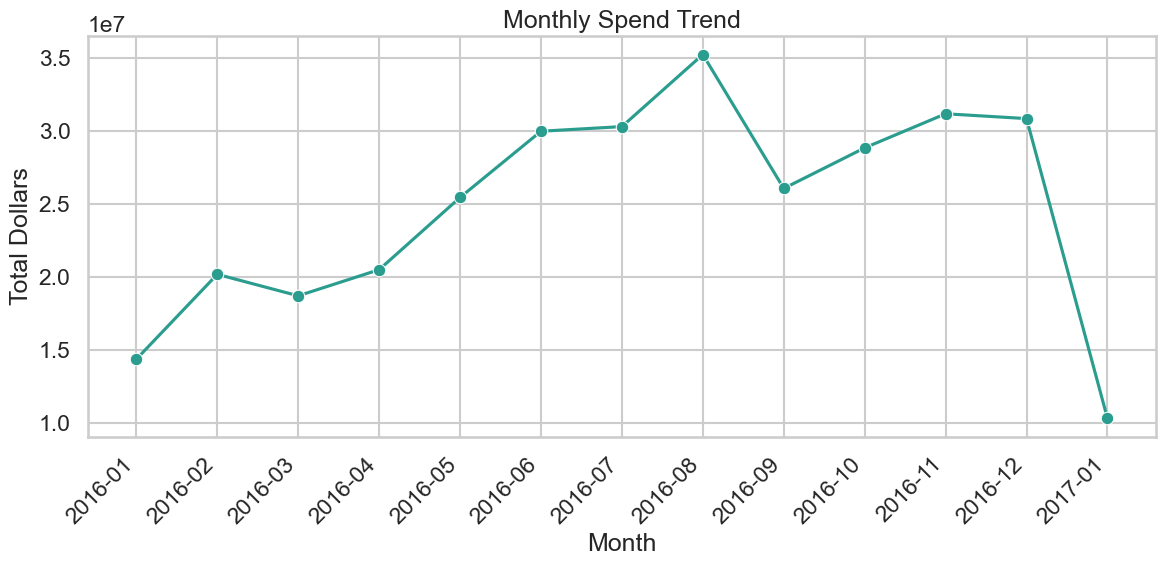

In [ ]:
months = [r["Month"] for r in month_aggs]
values = [r["TotalDollars"] for r in month_aggs]

plt.figure(figsize=(12, 6))
sns.lineplot(x=months, y=values, marker="o", color="#2a9d8f")
plt.title("Monthly Spend Trend")
plt.xlabel("Month")
plt.ylabel("Total Dollars")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
def month_aggregates(invoices):
    stats = defaultdict(lambda: {"dollars": 0, "qty": 0})
    for r in invoices:
        if r["InvoiceDate"]:
            key = r["InvoiceDate"].strftime("%Y-%m")
            stats[key]["dollars"] += r["Dollars"]
            stats[key]["qty"] += r["Quantity"]
    return sorted(
        [{"Month": k, "TotalDollars": v["dollars"], "TotalQuantity": v["qty"]}
         for k, v in stats.items()],
        key=lambda x: x["Month"]
    )

month_aggs = month_aggregates(invoices)


### Observed vs Reference Unit Cost

- Compares **observed average unit cost** (from invoices) vs **reference** (price snapshot).
- The dashed diagonal is **parity**; points above indicate observed > reference (potential overpayment).
- To focus on extremes, sort by `abs(Delta)` and plot the top 30.

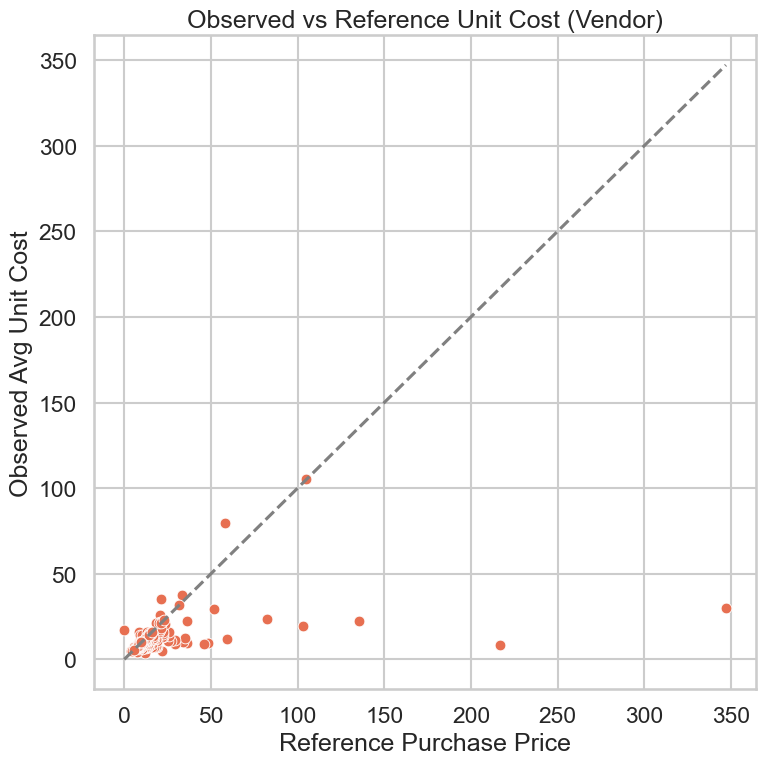

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

def _ensure_vendor_aggregates(invoices):
    stats = defaultdict(lambda: {"dollars":0.0,"qty":0.0})
    for r in invoices:
        v = r.get("VendorName","")
        s = stats[v]
        s["dollars"] += r.get("Dollars",0.0)
        s["qty"] += r.get("Quantity",0.0)
    out = []
    for v,s in stats.items():
        auc = (s["dollars"]/s["qty"]) if s["qty"] else 0.0
        out.append({"VendorName":v,"AvgUnitCost":auc,"TotalDollars":s["dollars"],"TotalQuantity":s["qty"]})
    return out

def _price_reference_by_vendor(prices):
    stats = defaultdict(lambda: {"sum":0.0,"n":0})
    for r in prices:
        v = r.get("VendorName","")
        s = stats[v]
        s["sum"] += r.get("PurchasePrice",0.0)
        s["n"] += 1
    return {v:(s["sum"]/s["n"]) if s["n"] else 0.0 for v,s in stats.items()}

def _compare_vendor_costs(vendor_aggs, vendor_price_ref):
    comp = []
    for row in vendor_aggs:
        v = row["VendorName"]
        ref = vendor_price_ref.get(v, 0.0)
        comp.append({
            "VendorName": v,
            "ObservedAvgUnitCost": row["AvgUnitCost"],
            "ReferencePurchasePrice": ref,
            "Delta": row["AvgUnitCost"] - ref
        })
    comp.sort(key=lambda x: abs(x["Delta"]), reverse=True)
    return comp

try:
    vendor_aggs
except NameError:
    vendor_aggs = _ensure_vendor_aggregates(invoices)

try:
    price_ref
except NameError:
    price_ref = _price_reference_by_vendor(prices)

try:
    comp
except NameError:
    comp = _compare_vendor_costs(vendor_aggs, price_ref)

obs = [r["ObservedAvgUnitCost"] for r in comp]
ref = [r["ReferencePurchasePrice"] for r in comp]

plt.figure(figsize=(8, 8))
sns.scatterplot(x=ref, y=obs, s=60, color="#e76f51")
maxv = max(max(ref), max(obs)) if ref and obs else 1
plt.plot([0, maxv], [0, maxv], ls="--", color="gray")
plt.title("Observed vs Reference Unit Cost (Vendor)")
plt.xlabel("Reference Purchase Price")
plt.ylabel("Observed Avg Unit Cost")
plt.tight_layout()
plt.show()

In [ ]:
def price_reference_by_vendor(prices):
    ref = defaultdict(list)
    for r in prices:
        ref[r["VendorName"]].append(r["PurchasePrice"])
    return {k: sum(v)/len(v) for k, v in ref.items() if v}

price_ref = price_reference_by_vendor(prices)


ABC analysis ranks vendors by cumulative spend share, labeling A (~top 80%), B (~next 15%), and C (~remaining 5%) to prioritize control and replenishment policies.

In [ ]:
abc_data = []
total_value = sum(v["TotalDollars"] for v in vendor_aggs)

running = 0
for v in vendor_aggs:
    running += v["TotalDollars"]
    pct = running / total_value
    if pct <= 0.7:
        cls = "A"
    elif pct <= 0.9:
        cls = "B"
    else:
        cls = "C"

    abc_data.append({
        "VendorName": v["VendorName"],
        "TotalDollars": v["TotalDollars"],
        "ABC_Class": cls
    })


In [ ]:
abc_df = pd.DataFrame(abc_data)
abc_df.head(10)

,VendorName,TotalDollars,ABC_Class
0,DIAGEO NORTH AMERICA INC,50959796.85,A
1,MARTIGNETTI COMPANIES,27861690.02,A
2,JIM BEAM BRANDS COMPANY,24203151.05,A
3,PERNOD RICARD USA,24124091.56,A
4,BACARDI USA INC,17624378.72,A
5,CONSTELLATION BRANDS INC,15573917.90,A
6,BROWN-FORMAN CORP,13529433.08,A
7,ULTRA BEVERAGE COMPANY LLP,13210613.93,A
8,E & J GALLO WINERY,12289608.09,A
9,M S WALKER INC,10935817.30,A


In [ ]:
ORDER_COST = 500
HOLDING_RATE = 0.20

eoq_results = []
for v in vendor_aggs:
    demand = v["TotalQuantity"]
    price = v["AvgUnitCost"]
    holding_cost = price * HOLDING_RATE
    if holding_cost > 0:
        eoq = math.sqrt((2 * demand * ORDER_COST) / holding_cost)
    else:
        eoq = 0

    eoq_results.append({
        "VendorName": v["VendorName"],
        "EOQ": round(eoq, 2)
    })


In [ ]:
eoq_df = pd.DataFrame(eoq_results)
eoq_df.sort_values("EOQ", ascending=False).head(10)

,VendorName,EOQ
0,DIAGEO NORTH AMERICA INC,54081.28
5,CONSTELLATION BRANDS INC,41675.00
2,JIM BEAM BRANDS COMPANY,39341.42
8,E & J GALLO WINERY,37481.97
1,MARTIGNETTI COMPANIES,35371.45
10,SAZERAC CO INC,31834.09
9,M S WALKER INC,29354.83
15,WINE GROUP INC,27393.63
4,BACARDI USA INC,24036.70
3,PERNOD RICARD USA,23719.21


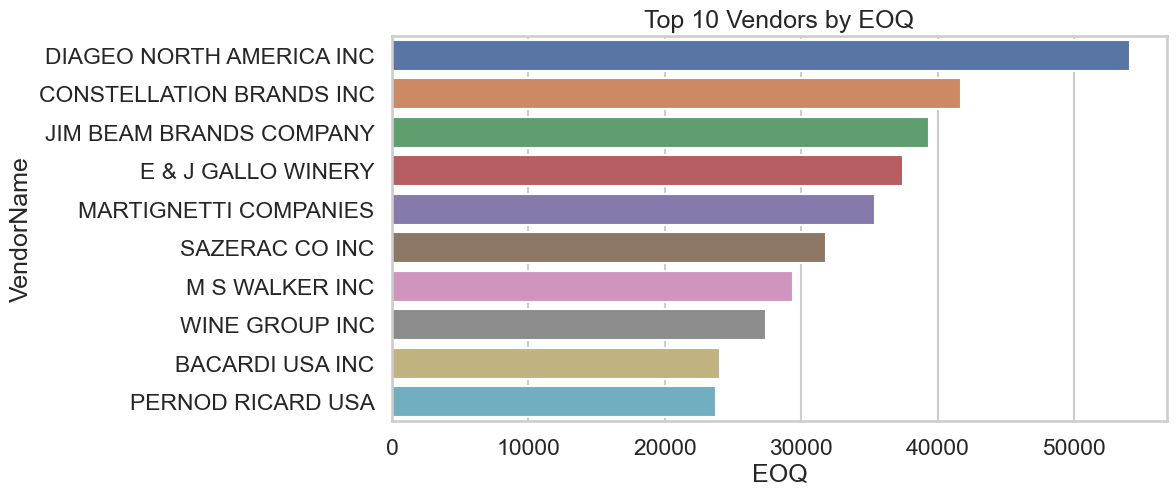

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=eoq_df.sort_values("EOQ", ascending=False).head(10),
    x="EOQ", y="VendorName"
)
plt.title("Top 10 Vendors by EOQ")
plt.show()


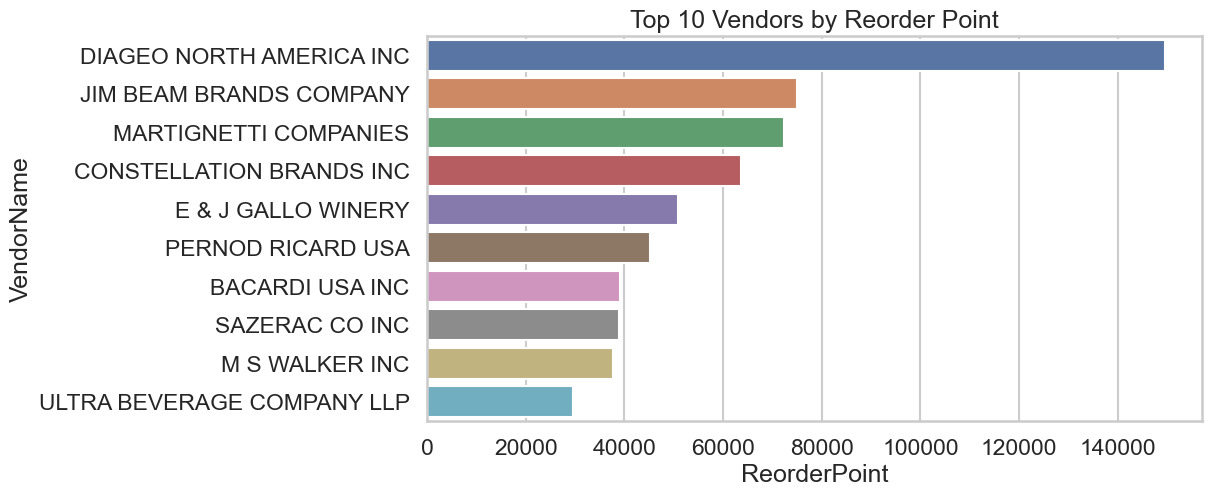

In [ ]:
LEAD_TIME_DAYS = 10

rop_results = []
for v in vendor_aggs:
    avg_daily_demand = v["TotalQuantity"] / 365
    rop = avg_daily_demand * LEAD_TIME_DAYS
    rop_results.append({
        "VendorName": v["VendorName"],
        "ReorderPoint": round(rop, 2)
    })

rop_df = pd.DataFrame(rop_results)
rop_df.sort_values("ReorderPoint", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=rop_df.sort_values("ReorderPoint", ascending=False).head(10),
    x="ReorderPoint", y="VendorName"
)
plt.title("Top 10 Vendors by Reorder Point")
plt.show()

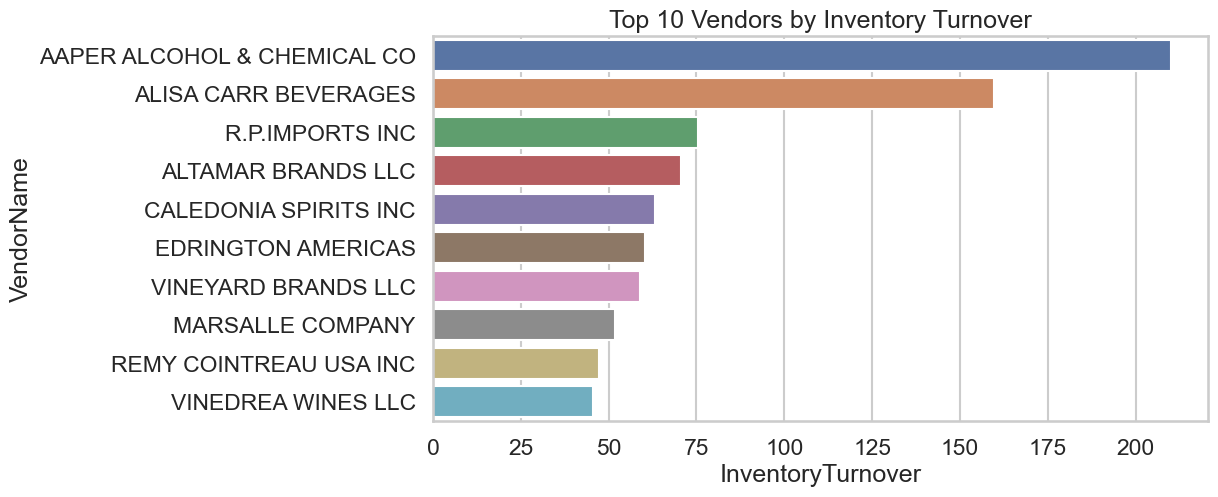

In [ ]:
turnover_results = []
for v in vendor_aggs:
    avg_inventory = v["TotalQuantity"] / 2  # proxy assumption
    turnover = v["TotalDollars"] / avg_inventory if avg_inventory else 0

    turnover_results.append({
        "VendorName": v["VendorName"],
        "InventoryTurnover": round(turnover, 2)
    })

turnover_df = pd.DataFrame(turnover_results)
turnover_df.sort_values("InventoryTurnover", ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=turnover_df.sort_values("InventoryTurnover", ascending=False).head(10),
    x="InventoryTurnover", y="VendorName"
)
plt.title("Top 10 Vendors by Inventory Turnover")
plt.show()


In [ ]:
fast_moving = [v for v in vendor_aggs if v["TotalQuantity"] > 2000000]
excess_stock = [v for v in vendor_aggs if v["TotalQuantity"] < 500000]

• Focus tight inventory control on A-class vendors.
• Reduce order quantities for C-class vendors.
• Use EOQ values to standardize procurement.
• Monitor reorder points to avoid stockouts.
• Improve turnover by clearing excess inventory.


In [ ]:
print("SUMMARY")
print("Rows:", len(invoices))
print("Total Quantity:", int(sum(r["Quantity"] for r in invoices)))
print("Total Dollars:", round(sum(r["Dollars"] for r in invoices), 2))
print("Total Freight:", round(sum(r["Freight"] for r in invoices), 2))

print("\nTOP 10 VENDORS BY SPEND")
for row in vendor_aggs[:10]:
    print(f"{row['VendorName']} | ${row['TotalDollars']:.2f} | Qty {int(row['TotalQuantity'])} | Avg Unit ${row['AvgUnitCost']:.4f}")

print("\nMONTH SUMMARY")
for row in month_aggs:
    print(f"{row['Month']} | ${row['TotalDollars']:.2f} | Qty {int(row['TotalQuantity'])}")

print("\nPRICE COMPARISON (Observed vs Reference)")
for row in comp[:10]:
    print(f"{row['VendorName']} | Obs ${row['ObservedAvgUnitCost']:.4f} | Ref ${row['ReferencePurchasePrice']:.4f} | Δ {row['Delta']:.4f}")

SUMMARY


NameError: name 'invoices' is not defined